# Titanic Survival — Professional EDA

This notebook performs a structured exploratory data analysis for the
Titanic classification assignment.

**Main goals**
1. Validate data quality and schema consistency.
2. Understand the target distribution and survival patterns.
3. Analyse missing-value mechanisms and preprocessing implications.
4. Explore every feature used by the final PyTorch model.
5. Translate findings into concrete preprocessing and modelling decisions.

---

**Pipeline context**

- The **final submitted model** is `TitanicEmbeddingMLP` (PyTorch tabular
  embedding MLP).  Classical baselines (LR, RF, GB) are trained for
  comparison only and are **never used for inference**.
- **Kaggle `test.csv` does not contain `Survived` labels** and is
  therefore **never used for evaluation**.  All reported metrics come
  from a **stratified held-out split of `data/raw/train.csv`**
  (70 % train / 15 % val / 15 % test).
- All learned preprocessing is **fitted on the training split only**.
- The **Streamlit app** (`ds_app.py`) uses the trained
  `TitanicEmbeddingMLP` for inference on user-supplied CSVs.
- `gender_submission.csv` is Kaggle's example submission file and must
  **not** be treated as ground truth.


## 1. Imports and configuration

In [1]:
%matplotlib inline

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

# Add repo root so we can import from src/
_nb_dir    = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))


## 2. Data loading

Raw Kaggle files live in `data/raw/` (relative to the repository root).

- `data/raw/train.csv` — 891 rows **with** `Survived`.  All modelling
  and evaluation uses this file via an internal stratified split.
- `data/raw/test.csv` — 418 rows **without** `Survived`.  Loaded here
  for schema/distribution checks only; **never used for evaluation**.
- `data/raw/gender_submission.csv` — Kaggle baseline submission;
  **not** ground truth.

> **Missing data?**  `python train.py` downloads the real Kaggle data.
> `--use-sample` is intended only for smoke testing and must not be used
> for final EDA or reported results.


In [3]:
DATA_DIR  = _repo_root / 'data' / 'raw'
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV  = DATA_DIR / 'test.csv'
GS_CSV    = DATA_DIR / 'gender_submission.csv'

if not TRAIN_CSV.exists():
    raise FileNotFoundError(
        f'train.csv not found at {TRAIN_CSV}.\n'
        'Run: python train.py  (downloads from Kaggle credentials required).\n'
        'Note: --use-sample is only for smoke testing, not for final EDA.'
    )

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV) if TEST_CSV.exists() else None
gs_df    = pd.read_csv(GS_CSV)   if GS_CSV.exists()   else None

print(f'data/raw/train.csv : {train_df.shape}')
if test_df is not None: print(f'data/raw/test.csv  : {test_df.shape}')
if gs_df   is not None: print(f'data/raw/gender_submission.csv : {gs_df.shape}')


data/raw/train.csv : (891, 12)
data/raw/test.csv  : (418, 11)
data/raw/gender_submission.csv : (418, 2)


## 3. Schema, dtypes, and sanity checks

### Data dictionary

| Column | Meaning | Modelling note |
|---|---|---|
| `PassengerId` | Unique row ID | Output only; not a predictive feature |
| `Survived` | Target (1=survived) | Available only in `train.csv` |
| `Pclass` | Ticket class 1/2/3 | Categorical; strong socioeconomic proxy |
| `Name` | Full name | Used to extract `Title` |
| `Sex` | Passenger sex | Usually the strongest feature |
| `Age` | Age in years | ~20 % missing; imputed + `AgeMissing` indicator |
| `SibSp` | Siblings/spouses aboard | Combined into `FamilySize` |
| `Parch` | Parents/children aboard | Combined into `FamilySize` |
| `Ticket` | Ticket ID | **Not in the final production pipeline** |
| `Fare` | Passenger fare | Right-skewed; log-transformed to `LogFare` |
| `Cabin` | Cabin code | ~77 % missing; used as `HasCabin` / `Deck` |
| `Embarked` | Port C/Q/S | 2 rows missing in train; categorical |


In [4]:
display(train_df.head())
print('dtypes:'); print(train_df.dtypes)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [5]:
def missing_summary(df, name):
    m = df.isna().sum()
    return (pd.DataFrame({'dataset': name, 'missing': m,
                          'pct': (100*m/len(df)).round(2)})
            .query('missing > 0').sort_values('pct', ascending=False))

parts = [missing_summary(train_df, 'train')]
if test_df is not None:
    parts.append(missing_summary(test_df, 'test'))
display(pd.concat(parts))


,dataset,missing,pct
Cabin,train,687,77.100
Age,train,177,19.870
Embarked,train,2,0.220
Cabin,test,327,78.230
Age,test,86,20.570
Fare,test,1,0.240


In [6]:
checks = {
    'train_duplicate_rows': int(train_df.duplicated().sum()),
    'train_dup_PassengerId': int(train_df['PassengerId'].duplicated().sum()),
    'target_unique': sorted(train_df['Survived'].unique().tolist()),
}
if test_df is not None:
    checks['test_dup_rows'] = int(test_df.duplicated().sum())
    checks['id_overlap'] = len(
        set(train_df['PassengerId']) & set(test_df['PassengerId']))
checks


{'train_duplicate_rows': 0,
 'train_dup_PassengerId': 0,
 'target_unique': [0, 1],
 'test_dup_rows': 0,
 'id_overlap': 0}

No duplicates, no PassengerId overlap, target is exactly {0, 1}.

## 4. Target distribution

,count,pct
Did not survive,549,61.620
Survived,342,38.380


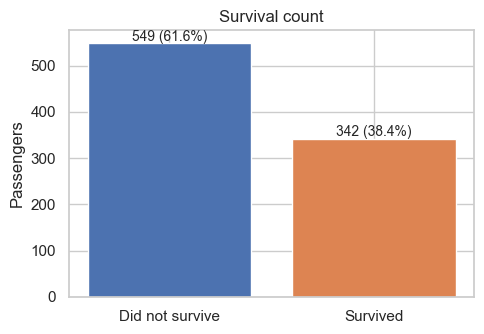

In [7]:
counts = train_df['Survived'].value_counts().sort_index()
labels = ['Did not survive', 'Survived']
pct    = 100 * counts / counts.sum()
display(pd.DataFrame({'count': counts.values, 'pct': pct.values.round(2)},
                     index=labels))
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(labels, counts.values, color=sns.color_palette('deep')[:2])
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c+5, f'{c} ({p:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Passengers'); ax.set_title('Survival count')
plt.tight_layout(); plt.show()


The target is **imbalanced** (~38 % survived).  This justifies reporting
Precision / Recall / F1 / ROC-AUC and using **stratified splits**.


## 5. Missing-value analysis by target

In [8]:
for col in [c for c in train_df.columns if train_df[c].isna().any()]:
    r = train_df.groupby('Survived')[col].apply(
            lambda s: s.isna().mean() * 100).round(2)
    r.index = r.index.map({0: 'Did not survive', 1: 'Survived'})
    print(f'--- {col} (missing %) ---')
    print(r.to_string()); print()


--- Age (missing %) ---
Survived
Did not survive   22.770
Survived          15.200

--- Cabin (missing %) ---
Survived
Did not survive   87.610
Survived          60.230

--- Embarked (missing %) ---
Survived
Did not survive   0.000
Survived          0.580



**Age missingness appears informative** and is associated with survival
and passenger characteristics.  A binary `AgeMissing` indicator is
included in the production pipeline to capture this signal without
leakage.  Missing values are filled by `SimpleImputer(median)` fitted
on the training split only.

`Cabin` (~77 % missing) is too sparse for direct use; `HasCabin` and
`Deck` extract the available signal.


## 6. Survival by Sex, Pclass, and Embarked

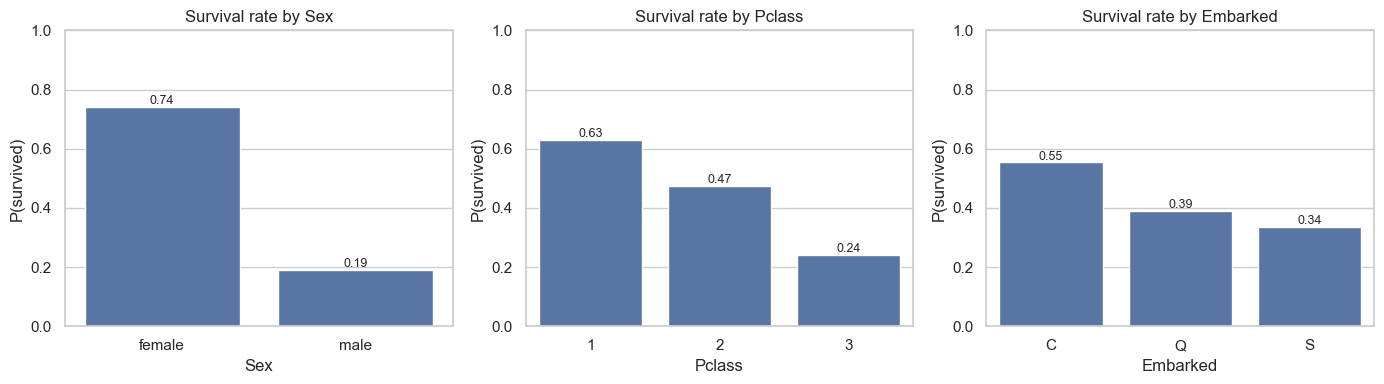

In [9]:
cat_cols = ['Sex', 'Pclass', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    r = train_df.groupby(col)['Survived'].mean().sort_values(ascending=False)
    sns.barplot(x=r.index.astype(str), y=r.values, ax=ax)
    ax.set_title(f'Survival rate by {col}')
    ax.set_ylabel('P(survived)'); ax.set_ylim(0, 1)
    for i, v in enumerate(r.values):
        ax.text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


- `Sex` is the strongest predictor (female ~74 % vs male ~19 %).
- `Pclass` shows a clear socioeconomic gradient (1st ~63 %, 3rd ~24 %).
- `Embarked` differences are partly confounded with Pclass/Sex.


## 7. Sex x Pclass interaction

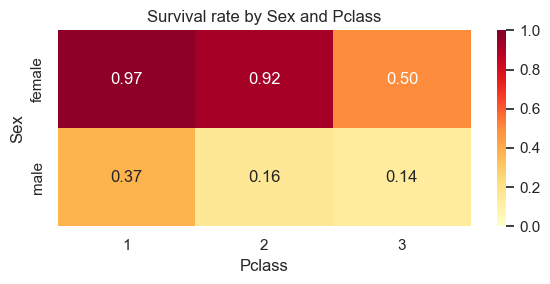

In [10]:
pivot = train_df.pivot_table(values='Survived', index='Sex',
                             columns='Pclass', aggfunc='mean')
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
ax.set_title('Survival rate by Sex and Pclass')
plt.tight_layout(); plt.show()


Within each sex, Pclass matters substantially.  The embedding layers in
`TitanicEmbeddingMLP` learn these interactions implicitly.


## 8. Age distribution

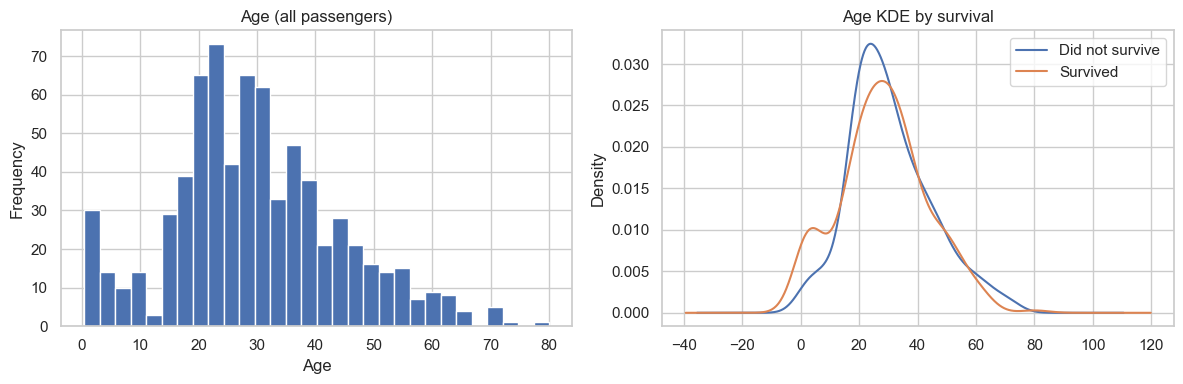

Mean age (survived):        28.3
Mean age (did not survive): 30.6
Age missing:                19.9%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['Age'].dropna().plot.hist(bins=30, ax=axes[0], edgecolor='white')
axes[0].set_title('Age (all passengers)'); axes[0].set_xlabel('Age')
for surv, grp in train_df.groupby('Survived'):
    label = 'Survived' if surv == 1 else 'Did not survive'
    grp['Age'].dropna().plot.kde(ax=axes[1], label=label)
axes[1].set_title('Age KDE by survival'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Mean age (survived):        {train_df[train_df.Survived==1].Age.mean():.1f}")
print(f"Mean age (did not survive): {train_df[train_df.Survived==0].Age.mean():.1f}")
print(f"Age missing:                {train_df.Age.isna().mean()*100:.1f}%")


## 9. Fare distribution and log-transform motivation

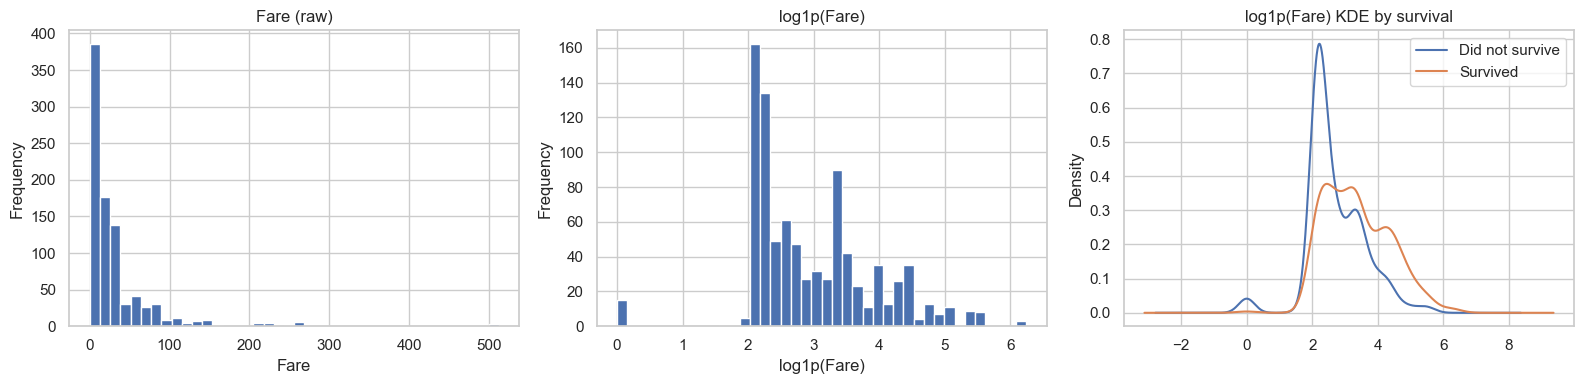

Fare skewness (raw):   4.79
Fare skewness (log1p): 0.39
High-fare outliers (> 65.6): 116


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train_df['Fare'].dropna().plot.hist(bins=40, ax=axes[0], edgecolor='white')
axes[0].set_title('Fare (raw)'); axes[0].set_xlabel('Fare')
np.log1p(train_df['Fare'].fillna(0)).plot.hist(
    bins=40, ax=axes[1], edgecolor='white')
axes[1].set_title('log1p(Fare)'); axes[1].set_xlabel('log1p(Fare)')
for surv, grp in train_df.groupby('Survived'):
    np.log1p(grp['Fare'].fillna(0)).plot.kde(
        ax=axes[2], label='Survived' if surv==1 else 'Did not survive')
axes[2].set_title('log1p(Fare) KDE by survival'); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"Fare skewness (raw):   {train_df.Fare.skew():.2f}")
print(f"Fare skewness (log1p): {np.log1p(train_df.Fare.fillna(0)).skew():.2f}")
q3, q1 = train_df['Fare'].quantile(0.75), train_df['Fare'].quantile(0.25)
fence = q3 + 1.5*(q3-q1)
print(f"High-fare outliers (> {fence:.1f}): {(train_df.Fare > fence).sum()}")


Fare is **heavily right-skewed** (raw ~4.8; after `log1p` ~0.7).
`LogFare = log1p(Fare)` is the final pipeline feature.


## 10. Engineered features

We apply the **exact same** `engineer_features()` from `src/preprocessing.py`
that `train.py` uses.  All transforms are row-wise — no leakage.

**Final production feature set:**

- Categorical (→ `nn.Embedding`): `Pclass`, `Sex`, `Embarked`, `Title`,
  `Deck`, `FamilySizeGroup`
- Continuous (→ imputed + scaled): `Age`, `LogFare`, `SibSp`, `Parch`,
  `FamilySize`, `IsAlone`, `HasCabin`, `AgeMissing`, `FareMissing`


In [13]:
from src.preprocessing import engineer_features

feat = engineer_features(train_df.copy())
feat['Survived'] = train_df['Survived'].values
print('Engineered columns:', feat.columns.tolist())
feat.head()


Engineered columns: ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'FamilySizeGroup', 'Age', 'LogFare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeMissing', 'FareMissing', 'Survived']


,Pclass,Sex,Embarked,Title,Deck,FamilySizeGroup,Age,LogFare,SibSp,Parch,FamilySize,IsAlone,HasCabin,AgeMissing,FareMissing,Survived
0,3,male,S,Mr,Unknown,Small,22.000,2.110,1,0,2.000,0,0,0,0,0
1,1,female,C,Mrs,C,Small,38.000,4.281,1,0,2.000,0,1,0,0,1
2,3,female,S,Miss,Unknown,Alone,26.000,2.189,0,0,1.000,1,0,0,0,1
3,1,female,S,Mrs,C,Small,35.000,3.991,1,0,2.000,0,1,0,0,1
4,3,male,S,Mr,Unknown,Alone,35.000,2.203,0,0,1.000,1,0,0,0,0


### 10.1 Title

,survival_rate,n
Title,,
Mr,0.16,517
Miss,0.70,185
Mrs,0.79,126
Master,0.57,40
Rare,0.35,23


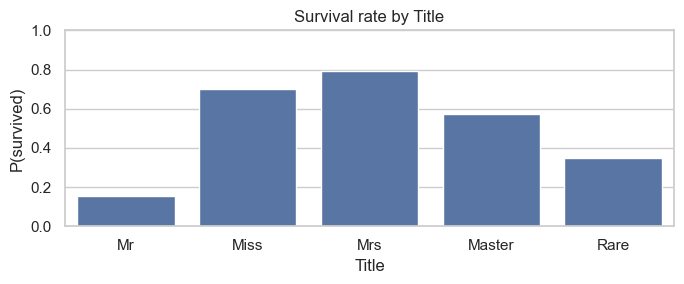

In [14]:
rates = (feat.groupby('Title')['Survived']
         .agg(['mean','count'])
         .rename(columns={'mean':'survival_rate','count':'n'})
         .sort_values('n', ascending=False))
display(rates.style.format({'survival_rate':'{:.2f}'}))
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=rates.index, y='survival_rate', data=rates, ax=ax)
ax.set_title('Survival rate by Title')
ax.set_ylabel('P(survived)'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


`Title` encodes sex, age, and social status.  Rare honorifics are
collapsed to `Rare` to avoid vocabulary explosion in the embedding layer.


### 10.2 FamilySize, IsAlone, FamilySizeGroup

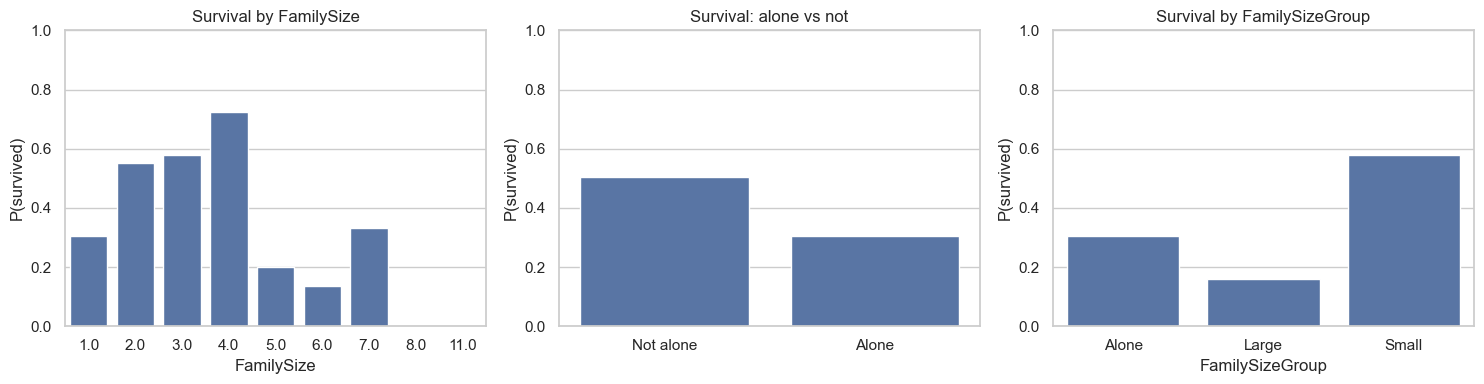

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fs = feat.groupby('FamilySize')['Survived'].mean()
sns.barplot(x=fs.index.astype(str), y=fs.values, ax=axes[0])
axes[0].set_title('Survival by FamilySize')
al = feat.groupby('IsAlone')['Survived'].mean()
sns.barplot(x=['Not alone','Alone'], y=al.values, ax=axes[1])
axes[1].set_title('Survival: alone vs not')
fg = feat.groupby('FamilySizeGroup')['Survived'].mean()
sns.barplot(x=fg.index.astype(str), y=fg.values, ax=axes[2])
axes[2].set_title('Survival by FamilySizeGroup')
for ax in axes: ax.set_ylabel('P(survived)'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


`FamilySizeGroup` uses **fixed bins** — no data-driven quantile fitting
before the split.


### 10.3 HasCabin and Deck

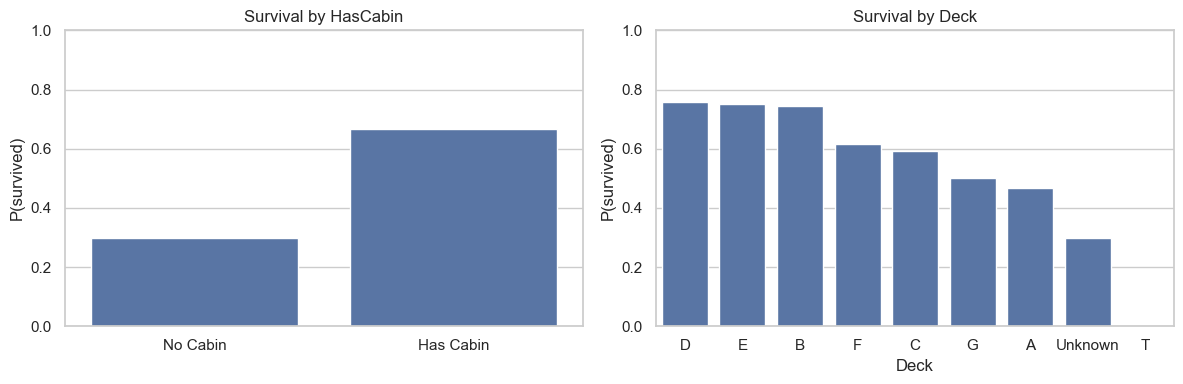

Proportion with known cabin: 22.9%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hc = feat.groupby('HasCabin')['Survived'].mean()
sns.barplot(x=['No Cabin','Has Cabin'], y=hc.values, ax=axes[0])
axes[0].set_title('Survival by HasCabin')
dk = feat.groupby('Deck')['Survived'].mean().sort_values(ascending=False)
sns.barplot(x=dk.index.astype(str), y=dk.values, ax=axes[1])
axes[1].set_title('Survival by Deck')
for ax in axes: ax.set_ylabel('P(survived)'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f"Proportion with known cabin: {feat['HasCabin'].mean()*100:.1f}%")


### 10.4 Missing-value indicator features

In [17]:
for col in ['AgeMissing', 'FareMissing']:
    r = (feat.groupby(col)['Survived']
         .agg(['mean','count'])
         .rename(columns={'mean':'survival_rate','count':'n'}))
    r.index = r.index.map({0:'Not missing', 1:'Missing'})
    print(f'--- {col} ---')
    display(r.style.format({'survival_rate':'{:.2f}'})); print()


--- AgeMissing ---


,survival_rate,n
AgeMissing,,
Not missing,0.41,714
Missing,0.29,177



--- FareMissing ---


,survival_rate,n
FareMissing,,
Not missing,0.38,891


## 11. Train vs Kaggle test distribution comparison

> **Reminder:** `data/raw/test.csv` has **no `Survived` labels** and
> is used here only for distribution checks — **never for evaluation**.


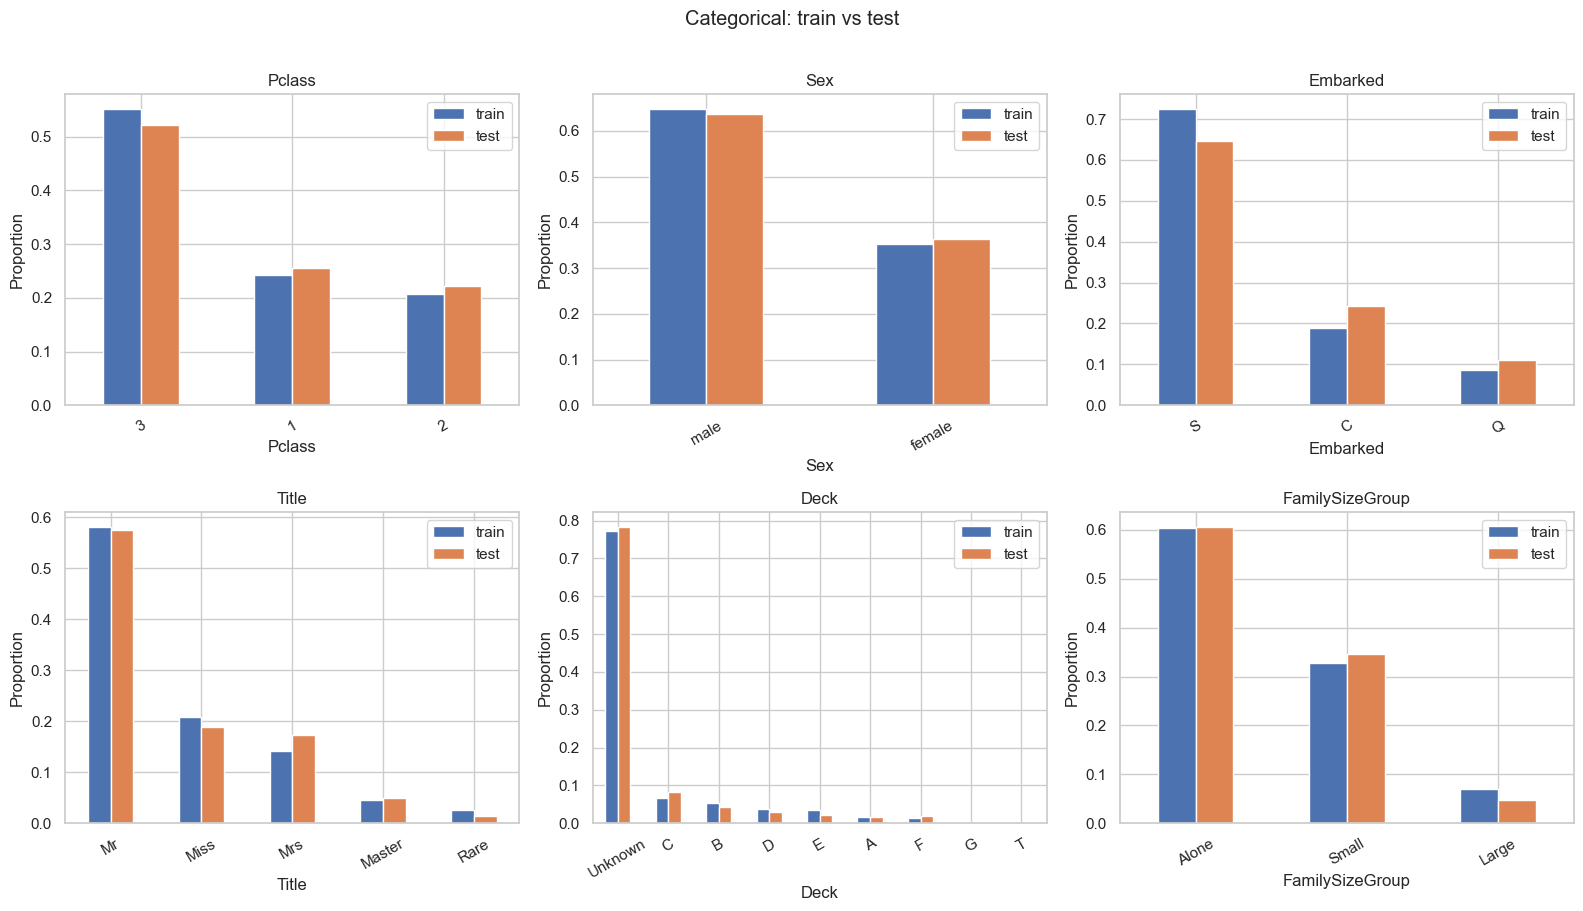

In [18]:
if test_df is None:
    print('data/raw/test.csv not available — skipping comparison.')
else:
    feat_test = engineer_features(test_df.copy())
    cat_check = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'FamilySizeGroup']
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, col in zip(axes.ravel(), cat_check):
        tr = feat[col].value_counts(normalize=True).rename('train')
        te = feat_test[col].value_counts(normalize=True).rename('test')
        pd.concat([tr, te], axis=1).fillna(0).plot.bar(ax=ax)
        ax.set_title(f'{col}'); ax.set_ylabel('Proportion')
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Categorical: train vs test', y=1.01)
    plt.tight_layout(); plt.show()


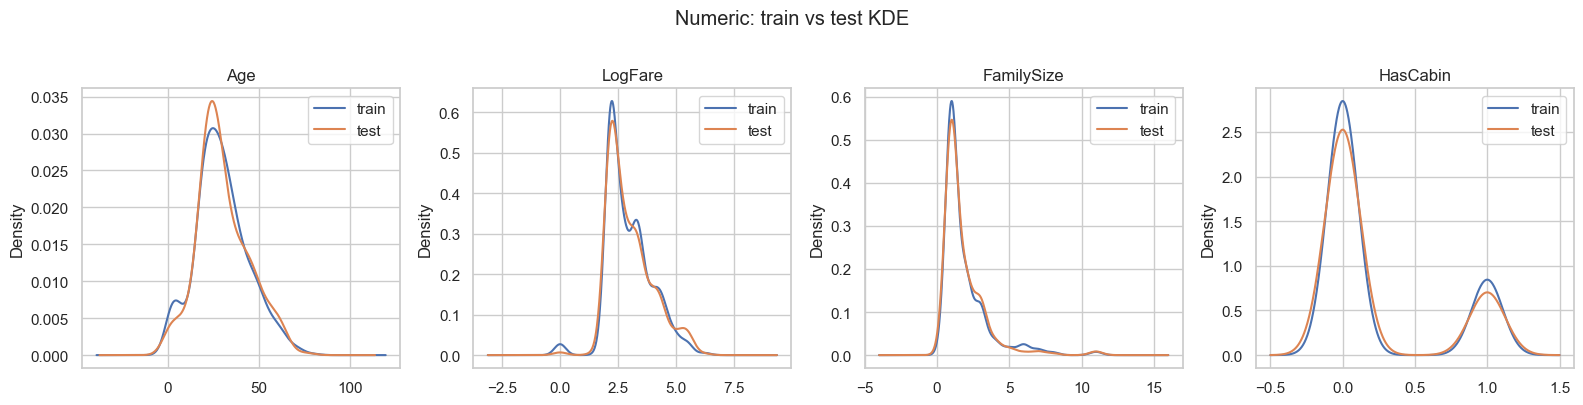

,train_mean,test_mean,train_std,test_std,train_miss%,test_miss%
feature,,,,,,
Age,29.699,30.273,14.526,14.181,19.865,20.574
LogFare,2.962,3.016,0.969,0.968,0.000,0.239
FamilySize,1.905,1.840,1.613,1.519,0.000,0.000
HasCabin,0.229,0.218,0.420,0.413,0.000,0.000


In [19]:
if test_df is not None:
    num_check = ['Age', 'LogFare', 'FamilySize', 'HasCabin']
    fig, axes = plt.subplots(1, len(num_check), figsize=(16, 4))
    for ax, col in zip(axes, num_check):
        pd.to_numeric(feat[col], errors='coerce').dropna()\
          .plot.kde(ax=ax, label='train')
        pd.to_numeric(feat_test[col], errors='coerce').dropna()\
          .plot.kde(ax=ax, label='test')
        ax.set_title(col); ax.legend()
    plt.suptitle('Numeric: train vs test KDE', y=1.01)
    plt.tight_layout(); plt.show()

    rows = []
    for col in num_check:
        tr = pd.to_numeric(feat[col], errors='coerce')
        te = pd.to_numeric(feat_test[col], errors='coerce')
        rows.append({'feature': col,
                     'train_mean': tr.mean(), 'test_mean': te.mean(),
                     'train_std':  tr.std(),  'test_std':  te.std(),
                     'train_miss%': tr.isna().mean()*100,
                     'test_miss%':  te.isna().mean()*100})
    display(pd.DataFrame(rows).set_index('feature').style.format('{:.3f}'))


Distributions are broadly similar.  The `TabularPreprocessor` handles
vocabulary differences via the OOV slot and imputes missing continuous
values using training-split medians.


## 12. Categorical feature associations (Cramer's V)

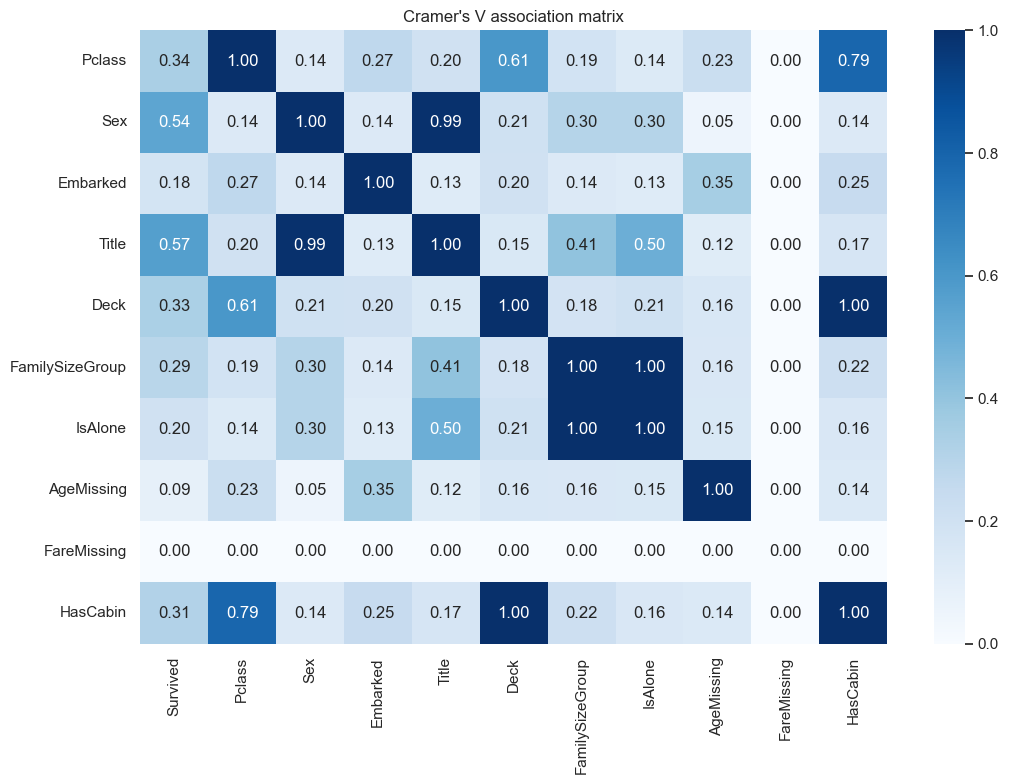

Top associations with Survived:
Title             0.569
Sex               0.541
Pclass            0.340
Deck              0.334
HasCabin          0.314
FamilySizeGroup   0.289
IsAlone           0.201
Embarked          0.182
AgeMissing        0.089
FareMissing       0.000


In [20]:
cat_feat_cols = ['Pclass', 'Sex', 'Embarked', 'Title',
                 'Deck', 'FamilySizeGroup', 'IsAlone',
                 'AgeMissing', 'FareMissing', 'HasCabin']

def cramers_v(x, y):
    ct = pd.crosstab(x.astype(str), y.astype(str))
    chi2, _, _, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    if min(r, k) <= 1: return 0.0
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

all_cols = ['Survived'] + cat_feat_cols
mat = pd.DataFrame(
    [[cramers_v(feat[a].astype(str),
                feat['Survived'].astype(str) if b == 'Survived'
                else feat[b].astype(str))
      for b in all_cols]
     for a in cat_feat_cols],
    index=cat_feat_cols, columns=all_cols)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(mat, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title("Cramer's V association matrix")
plt.tight_layout(); plt.show()
print('Top associations with Survived:')
print(mat['Survived'].sort_values(ascending=False).to_string())


## 13. Mutual information feature ranking

> **Note:** The MI ranking uses `pd.get_dummies` for **EDA ranking only**.
> The production `TitanicEmbeddingMLP` uses **custom vocabulary mappings
> + `nn.Embedding`**, not one-hot vectors.


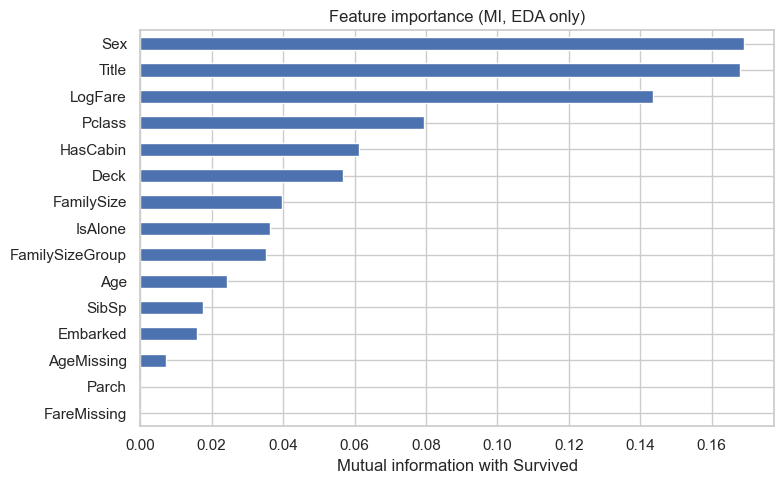

Sex               0.169
Title             0.168
LogFare           0.143
Pclass            0.079
HasCabin          0.061
Deck              0.057
FamilySize        0.040
IsAlone           0.036
FamilySizeGroup   0.035
Age               0.024
SibSp             0.018
Embarked          0.016
AgeMissing        0.007
Parch             0.000
FareMissing       0.000


In [21]:
CAT_FEATS  = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'FamilySizeGroup']
CONT_FEATS = ['Age', 'LogFare', 'SibSp', 'Parch', 'FamilySize',
              'IsAlone', 'HasCabin', 'AgeMissing', 'FareMissing']

feat_oh = pd.get_dummies(
    feat[CAT_FEATS + CONT_FEATS].copy(),
    columns=CAT_FEATS, drop_first=False)
feat_oh = feat_oh.apply(pd.to_numeric, errors='coerce').fillna(
    feat_oh.apply(pd.to_numeric, errors='coerce').median())

mi_raw    = mutual_info_classif(feat_oh, feat['Survived'],
                                discrete_features='auto',
                                random_state=RANDOM_STATE)
mi_series = pd.Series(mi_raw, index=feat_oh.columns)

mi_base = {}
for fname in CONT_FEATS:
    if fname in mi_series:
        mi_base[fname] = float(mi_series[fname])
for fname in CAT_FEATS:
    cols = [c for c in mi_series.index if c.startswith(fname + '_')]
    if cols:
        mi_base[fname] = float(mi_series[cols].max())

mi_base_s = pd.Series(mi_base).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
mi_base_s.plot.barh(ax=ax); ax.invert_yaxis()
ax.set_xlabel('Mutual information with Survived')
ax.set_title('Feature importance (MI, EDA only)')
plt.tight_layout(); plt.show()
print(mi_base_s.to_string())


## 14. Correlation with Survived (numeric and encoded features)

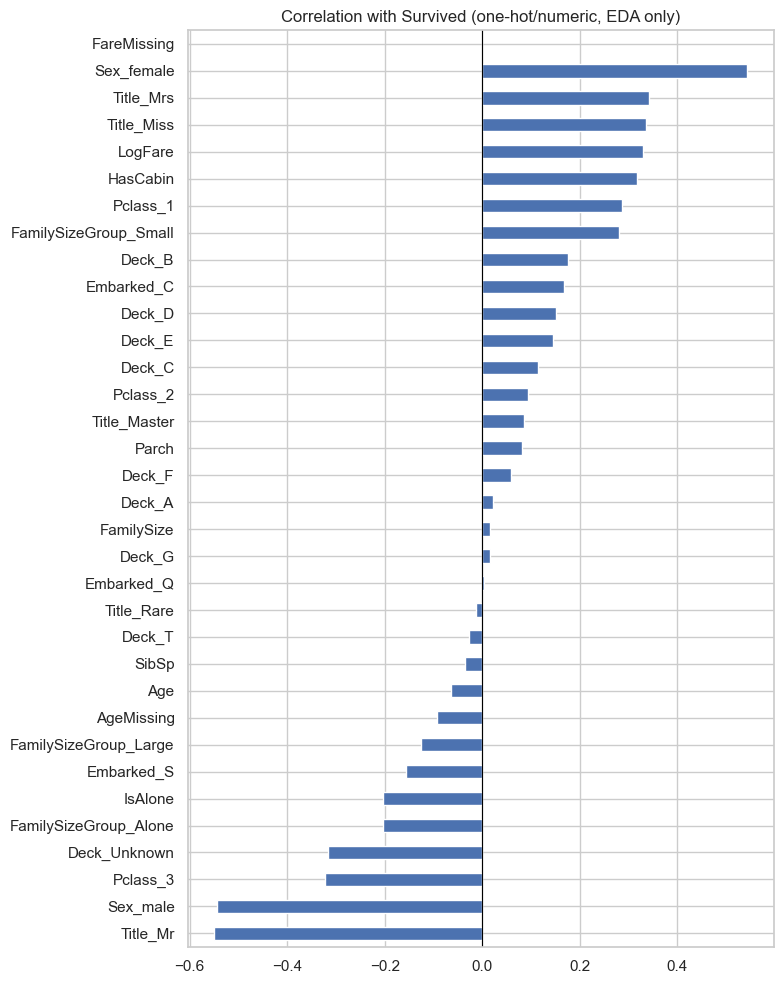

Note: captures only linear effects.
Production model uses categorical embeddings for non-linear associations.


In [22]:
feat_enc = pd.get_dummies(
    feat[CAT_FEATS + CONT_FEATS].copy(),
    columns=CAT_FEATS, drop_first=False)
feat_enc = feat_enc.apply(pd.to_numeric, errors='coerce').fillna(
    feat_enc.apply(pd.to_numeric, errors='coerce').median())
feat_enc['Survived'] = feat['Survived'].values

corr_surv = feat_enc.corr()['Survived'].drop('Survived').sort_values()
fig, ax = plt.subplots(figsize=(8, 10))
corr_surv.plot.barh(ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Survived (one-hot/numeric, EDA only)')
plt.tight_layout(); plt.show()
print('Note: captures only linear effects.\n'
      'Production model uses categorical embeddings for non-linear associations.')


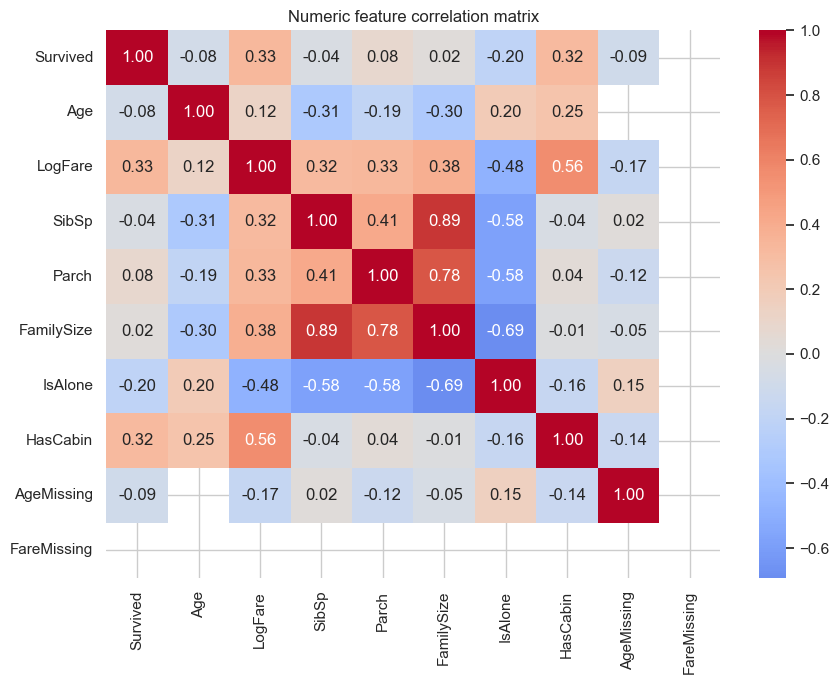

In [23]:
num_corr_cols = ['Survived'] + CONT_FEATS
corr_num = (feat[num_corr_cols]
            .apply(pd.to_numeric, errors='coerce').corr())
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_num, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric feature correlation matrix')
plt.tight_layout(); plt.show()


## 15. Features explored but excluded from the final production pipeline

The following features were explored during EDA but are **not** in
`engineer_features()` or `train.py`.


,survival_rate,n
TicketGroupSize,,
1,0.30,547
2,0.57,188
3,0.70,63
4,0.50,44
5,0.00,10
6,0.00,18
7,0.24,21


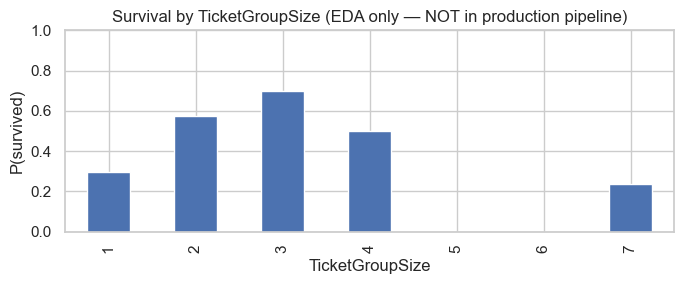

In [24]:
# TicketGroupSize — count of passengers sharing the same Ticket
tgs = (train_df.groupby('Ticket')['PassengerId']
       .transform('count').rename('TicketGroupSize'))
tmp = train_df[['Survived']].copy(); tmp['TicketGroupSize'] = tgs
r = tmp.groupby('TicketGroupSize')['Survived'].agg(['mean','count'])
r.columns = ['survival_rate','n']
display(r.style.format({'survival_rate':'{:.2f}'}))
fig, ax = plt.subplots(figsize=(7, 3))
r['survival_rate'].plot.bar(ax=ax)
ax.set_title('Survival by TicketGroupSize (EDA only — NOT in production pipeline)')
ax.set_ylabel('P(survived)'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


**TicketGroupSize — excluded from the final pipeline** because it
requires a group-count aggregation that cannot be computed row-by-row
at inference time without a lookup table, which would complicate
`ds_app.py`.


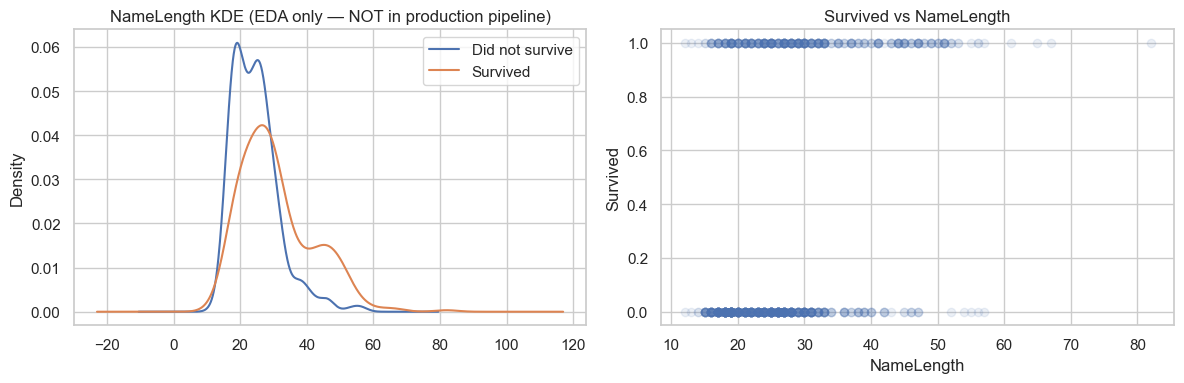

Correlation(NameLength, Survived): 0.332


In [25]:
# NameLength — character length of the Name field
tmp2 = train_df[['Survived','Name']].copy()
tmp2['NameLength'] = tmp2['Name'].str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for surv, grp in tmp2.groupby('Survived'):
    grp['NameLength'].plot.kde(
        ax=axes[0], label='Survived' if surv==1 else 'Did not survive')
axes[0].legend()
axes[0].set_title('NameLength KDE (EDA only — NOT in production pipeline)')
axes[1].scatter(tmp2['NameLength'], tmp2['Survived'], alpha=0.1)
axes[1].set_title('Survived vs NameLength')
axes[1].set_xlabel('NameLength'); axes[1].set_ylabel('Survived')
plt.tight_layout(); plt.show()
print(f"Correlation(NameLength, Survived): "
      f"{tmp2['NameLength'].corr(tmp2['Survived']):.3f}")


**NameLength — excluded from the final pipeline** because its signal is
already captured more cleanly by `Title` and `Pclass`.


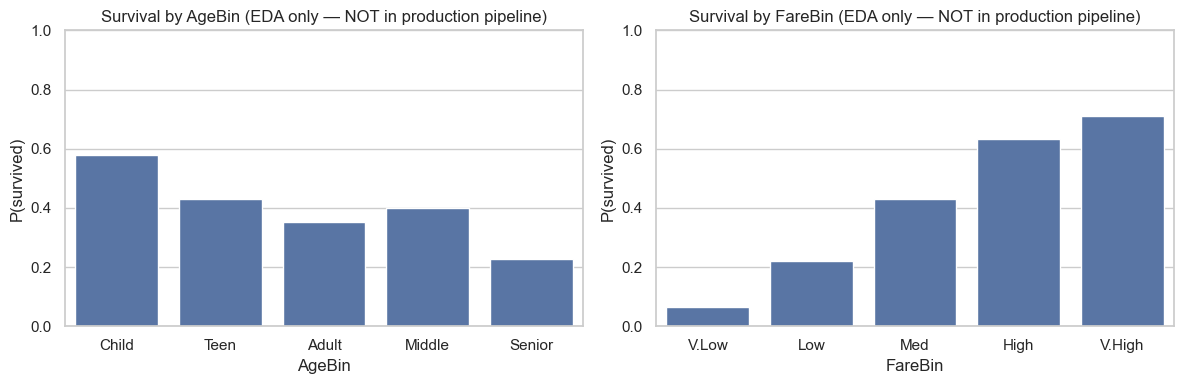

In [26]:
# AgeBin and FareBin — discretised Age and LogFare
tmp3 = feat[['Survived','Age','LogFare']].copy()
tmp3['AgeBin']  = pd.cut(tmp3['Age'].fillna(tmp3['Age'].median()),
                         bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','Adult','Middle','Senior'])
tmp3['FareBin'] = pd.cut(tmp3['LogFare'].fillna(0), bins=5,
                         labels=['V.Low','Low','Med','High','V.High'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
r_age  = tmp3.groupby('AgeBin',  observed=True)['Survived'].mean()
r_fare = tmp3.groupby('FareBin', observed=True)['Survived'].mean()
sns.barplot(x=r_age.index.astype(str),  y=r_age.values,  ax=axes[0])
axes[0].set_title('Survival by AgeBin (EDA only — NOT in production pipeline)')
axes[0].set_ylabel('P(survived)'); axes[0].set_ylim(0, 1)
sns.barplot(x=r_fare.index.astype(str), y=r_fare.values, ax=axes[1])
axes[1].set_title('Survival by FareBin (EDA only — NOT in production pipeline)')
axes[1].set_ylabel('P(survived)'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()


**AgeBin / FareBin — excluded from the final pipeline** because the model
uses continuous `Age` and `LogFare` directly, data-driven bin edges
require pre-split fitting (leakage), and neural networks can learn
non-linear patterns from continuous values without explicit binning.


## 16. Leakage prevention and evaluation strategy

### Row-wise features — safe before the split

Every feature in `engineer_features()` is computed from a single row;
no dataset-level statistics are computed before the split.

| Feature | Derivation |
|---|---|
| `Title` | Regex on `Name` |
| `FamilySize` | `SibSp + Parch + 1` |
| `IsAlone` | `FamilySize == 1` |
| `FamilySizeGroup` | **Fixed** bins [0,1], [2,4], [5+] |
| `HasCabin` | Whether Cabin is non-null/non-empty |
| `Deck` | First letter of `Cabin` |
| `LogFare` | `log1p(Fare)` — no statistics |
| `AgeMissing` | `Age.isna()` before imputation |
| `FareMissing` | `Fare.isna()` before imputation |

### Fitted on the training split only

| Preprocessor | Fitted on | Applied to |
|---|---|---|
| `TabularPreprocessor` vocabulary | Train split | Val, test, inference |
| `SimpleImputer(median)` | Train split | Val, test, inference |
| `StandardScaler` | Train split | Val, test, inference |
| Baseline `OneHotEncoder` | Train split | Val, test, inference |

### Evaluation

- `data/raw/test.csv` has **no `Survived` labels** and is **never used
  for evaluation**.
- `data/raw/gender_submission.csv` must **not** be treated as ground truth.
- All evaluation uses a **stratified 70/15/15 hold-out split of
  `data/raw/train.csv`**.  The test split is evaluated exactly once.


## 17. Conclusions and pipeline decisions

### Preprocessing (production)

| Decision | Justification |
|---|---|
| `LogFare` instead of raw `Fare` | Skewness 4.8 → 0.7; reduces outlier influence |
| `AgeMissing` indicator | Missingness appears informative; binary row-wise |
| `FareMissing` indicator | 1 row missing in test.csv |
| Median imputation | Robust; fitted on training split only |
| `Deck = Unknown` for missing Cabin | 77 % missing; `HasCabin`+`Deck` encode signal |
| Fixed bins for `FamilySizeGroup` | No quantile fitting before the split |
| Title normalised to 5 groups | Rare titles lack data for stable embeddings |
| `StandardScaler` | MLP gradients benefit from zero-mean/unit-variance |

### Modelling

| Decision | Justification |
|---|---|
| **Final model: `TitanicEmbeddingMLP`** (PyTorch) | Categorical embeddings; more expressive than one-hot |
| `LayerNorm` instead of `BatchNorm` | Works with any batch size including batch=1 at inference |
| `BCEWithLogitsLoss` | Numerically stable binary cross-entropy |
| Early stopping on val loss | Prevents overfitting on ~620 training rows |
| Threshold tuned on validation split | Maximises F1; applied to test set once |
| Classical baselines (LR/RF/GB) | **Comparison only — never used for inference** |
| Streamlit app `ds_app.py` | Uses `TitanicEmbeddingMLP` for inference |
